# USTA Pose — Symmetric Vocabulary Discovery
## Data Augmentation for Permutation Invariance

This notebook addresses the "Task Asymmetry" bias where the clustering previously 
separated identical physical behaviors depending on whether Person 1 or Person 2 performed them.
By duplicating every temporal window and swapping the features of P1 and P2 
(Data Augmentation), we enforce **permutation invariance**. 

The K-Means algorithm is trained on this perfectly symmetric dataset, forcing it 
to discover pure, role-agnostic communication states (e.g., "Person A acts, Person B observes") 
regardless of seating arrangement.


In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({'figure.figsize': (12, 7), 'figure.dpi': 120})
print("Imports successful.")


Imports successful.


In [2]:
DATA_DIR = "./devel/final_dataset_parquets"
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files.\n")

dfs = []
for f in parquet_files:
    try:
        df = pd.read_parquet(f)
        df['session_label'] = os.path.basename(f).replace('.parquet', '')
        if 'frame_interaction_valid' in df.columns:
            df = df[df['frame_interaction_valid'] == True]
        dfs.append(df)
    except Exception as e:
        pass
data = pd.concat(dfs, ignore_index=True)
print(f"Total valid frames: {len(data):,}")


Found 44 parquet files.

Total valid frames: 131,907


## 2. Feature Extraction & Data Augmentation (Swapping)

In [3]:
WINDOW_SIZE = 60
STEP_SIZE   = 30

def compute_window_features(w):
    feat = {}
    
    # A) Proxemics
    for col in ['dyad_root_distance', 'dyad_root_horizontal_distance', 'p1_head_to_p2_head_distance']:
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 1:
                feat[f'{col}_mean'] = s.mean()
                feat[f'{col}_std']  = s.std()
                feat[f'{col}_delta'] = s.iloc[-1] - s.iloc[0]
                
    # B) Gaze
    for person in ['p1', 'p2']:
        for g_col in ['gaze_to_other_head_angle_deg', 'gaze_to_dyad_ref_angle_deg']:
            col = f'{person}_{g_col}'
            if col in w.columns:
                s = w[col].dropna()
                if len(s) > 1:
                    feat[f'{col}_mean'] = s.mean()
                    if 'other_head' in col:
                        feat[f'{col}_std'] = s.std()
    
    g1 = w.get('p1_gaze_to_other_head_angle_deg')
    g2 = w.get('p2_gaze_to_other_head_angle_deg')
    if g1 is not None and g2 is not None:
        valid = g1.notna() & g2.notna()
        if valid.sum() > 0:
            feat['mutual_gaze_loose_ratio'] = ((g1[valid] < 15) & (g2[valid] < 15)).mean()
            feat['mutual_gaze_strict_ratio'] = ((g1[valid] < 5) & (g2[valid] < 5)).mean()
            
    if 'mutual_gaze_cos_min' in w.columns:
        s = w['mutual_gaze_cos_min'].dropna()
        if len(s) > 0:
            feat['mutual_gaze_cos_min_mean'] = s.mean()
            
    # C) Kinesics
    wrist_cols = [
        'p1_left_wrist_to_p2_right_wrist_distance', 'p1_right_wrist_to_p2_left_wrist_distance',
        'p1_left_wrist_to_p2_head_distance', 'p1_right_wrist_to_p2_head_distance',
        'p2_left_wrist_to_p1_head_distance', 'p2_right_wrist_to_p1_head_distance'
    ]
    for col in wrist_cols:
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 0:
                feat[f'{col}_mean'] = s.mean()
                feat[f'{col}_min']  = s.min()
                
    if 'p1_left_wrist_to_p2_right_wrist_distance' in w.columns and 'p1_right_wrist_to_p2_left_wrist_distance' in w.columns:
        m1 = w['p1_left_wrist_to_p2_right_wrist_distance'].min()
        m2 = w['p1_right_wrist_to_p2_left_wrist_distance'].min()
        feat['cross_wrist_min_distance'] = min(m1, m2)
        
    # D) Motion
    for person in ['p1', 'p2']:
        for mcol in [f'{person}_motion_speed', f'{person}_motion_energy_body']:
            if mcol in w.columns:
                s = w[mcol].dropna()
                if len(s) > 1:
                    feat[f'{mcol}_mean'] = s.mean()
                    feat[f'{mcol}_std']  = s.std()
                    feat[f'{mcol}_max']  = s.max()
                    
    if 'motion_energy_ratio_p1_over_p2' in w.columns:
        s = w['motion_energy_ratio_p1_over_p2'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) > 0:
            ratios = np.clip(s.values, 0.01, 100)
            feat['motion_log_ratio_mean'] = np.log(ratios).mean()
            feat['motion_log_ratio_std']  = np.log(ratios).std()
            
    return feat

def swap_features(feat):
    """Creates a perfectly mirrored version of the feature vector."""
    swap = {}
    for k, v in feat.items():
        # Motion ratio log(p1/p2) becomes log(p2/p1) = -log(p1/p2)
        if k == 'motion_log_ratio_mean':
            swap[k] = -v
        elif k == 'motion_log_ratio_std':
            swap[k] = v
        # Wrist cross distances
        elif k.startswith('p1_left_wrist_to_p2_right_wrist'):
            swap[k.replace('p1_left_wrist_to_p2_right_wrist', 'p1_right_wrist_to_p2_left_wrist')] = v
        elif k.startswith('p1_right_wrist_to_p2_left_wrist'):
            swap[k.replace('p1_right_wrist_to_p2_left_wrist', 'p1_left_wrist_to_p2_right_wrist')] = v
        elif k.startswith('p1_left_wrist_to_p2_head'):
            swap[k.replace('p1_left_wrist_to_p2_head', 'p2_left_wrist_to_p1_head')] = v
        elif k.startswith('p1_right_wrist_to_p2_head'):
            swap[k.replace('p1_right_wrist_to_p2_head', 'p2_right_wrist_to_p1_head')] = v
        elif k.startswith('p2_left_wrist_to_p1_head'):
            swap[k.replace('p2_left_wrist_to_p1_head', 'p1_left_wrist_to_p2_head')] = v
        elif k.startswith('p2_right_wrist_to_p1_head'):
            swap[k.replace('p2_right_wrist_to_p1_head', 'p1_right_wrist_to_p2_head')] = v
        # Standard p1/p2 swap
        elif k.startswith('p1_') and 'p2_' not in k:
            swap[k.replace('p1_', 'p2_')] = v
        elif k.startswith('p2_') and 'p1_' not in k:
            swap[k.replace('p2_', 'p1_')] = v
        # Everything else (dyad_, mutual_gaze_, cross_wrist_min_distance) remains the same
        else:
            swap[k] = v
    return swap

def extract_all_windows_augmented(data):
    all_windows = []
    
    sessions = data.groupby('session_label')
    for session_name, session_df in sessions:
        session_df = session_df.sort_values('frame_idx').reset_index(drop=True)
        n = len(session_df)
        
        for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
            end = start + WINDOW_SIZE
            w = session_df.iloc[start:end]
            
            # Original Window (p1, p2)
            feat = compute_window_features(w)
            feat['session_label'] = session_name
            feat['window_idx'] = start
            feat['is_swapped'] = 0
            all_windows.append(feat)
            
            # Swapped Window (p2, p1)
            feat_swap = swap_features(feat)
            feat_swap['session_label'] = session_name
            feat_swap['window_idx'] = start
            feat_swap['is_swapped'] = 1
            all_windows.append(feat_swap)
            
    return pd.DataFrame(all_windows)

window_df = extract_all_windows_augmented(data)
print(f"Extracted {len(window_df):,} windows (Original + Swapped).")

# VERIFICATION: Are the features perfectly symmetric?
f1 = window_df[window_df['is_swapped']==0]['p1_motion_speed_mean'].mean()
f2 = window_df[window_df['is_swapped']==1]['p2_motion_speed_mean'].mean()
assert np.isclose(f1, f2), "Swap logic failed!"
print("Symmetry verification passed: Data is perfectly balanced.")


Extracted 8,670 windows (Original + Swapped).
Symmetry verification passed: Data is perfectly balanced.


## 3. Symmetric K-Means Clustering

In [4]:
# Clean
meta_cols = ['session_label', 'window_idx', 'is_swapped']
feature_cols = [c for c in window_df.columns if c not in meta_cols]

thresh = int(len(feature_cols) * 0.7)
window_clean = window_df.dropna(subset=feature_cols, thresh=thresh).copy()
for c in feature_cols:
    if window_clean[c].isna().any():
        window_clean[c].fillna(window_clean[c].median(), inplace=True)

print(f"Windows for clustering: {len(window_clean):,}")

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(window_clean[feature_cols].values)

# Cluster (Let's use k=5 directly since we know the vocabulary scale)
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
window_clean['cluster'] = km.fit_predict(X)
print(f"K-Means (k={K}) completed. Silhouette: {silhouette_score(X, window_clean['cluster'].values, sample_size=2000):.4f}")


Windows for clustering: 8,670
K-Means (k=5) completed. Silhouette: 0.0752


## 4. Cluster Profiling (Role-Agnostic)

Since the clusters are symmetric, the designations "p1" and "p2" are arbitrary. 
We rename them to **"Person A"** and **"Person B"** for the heatmap visualization.


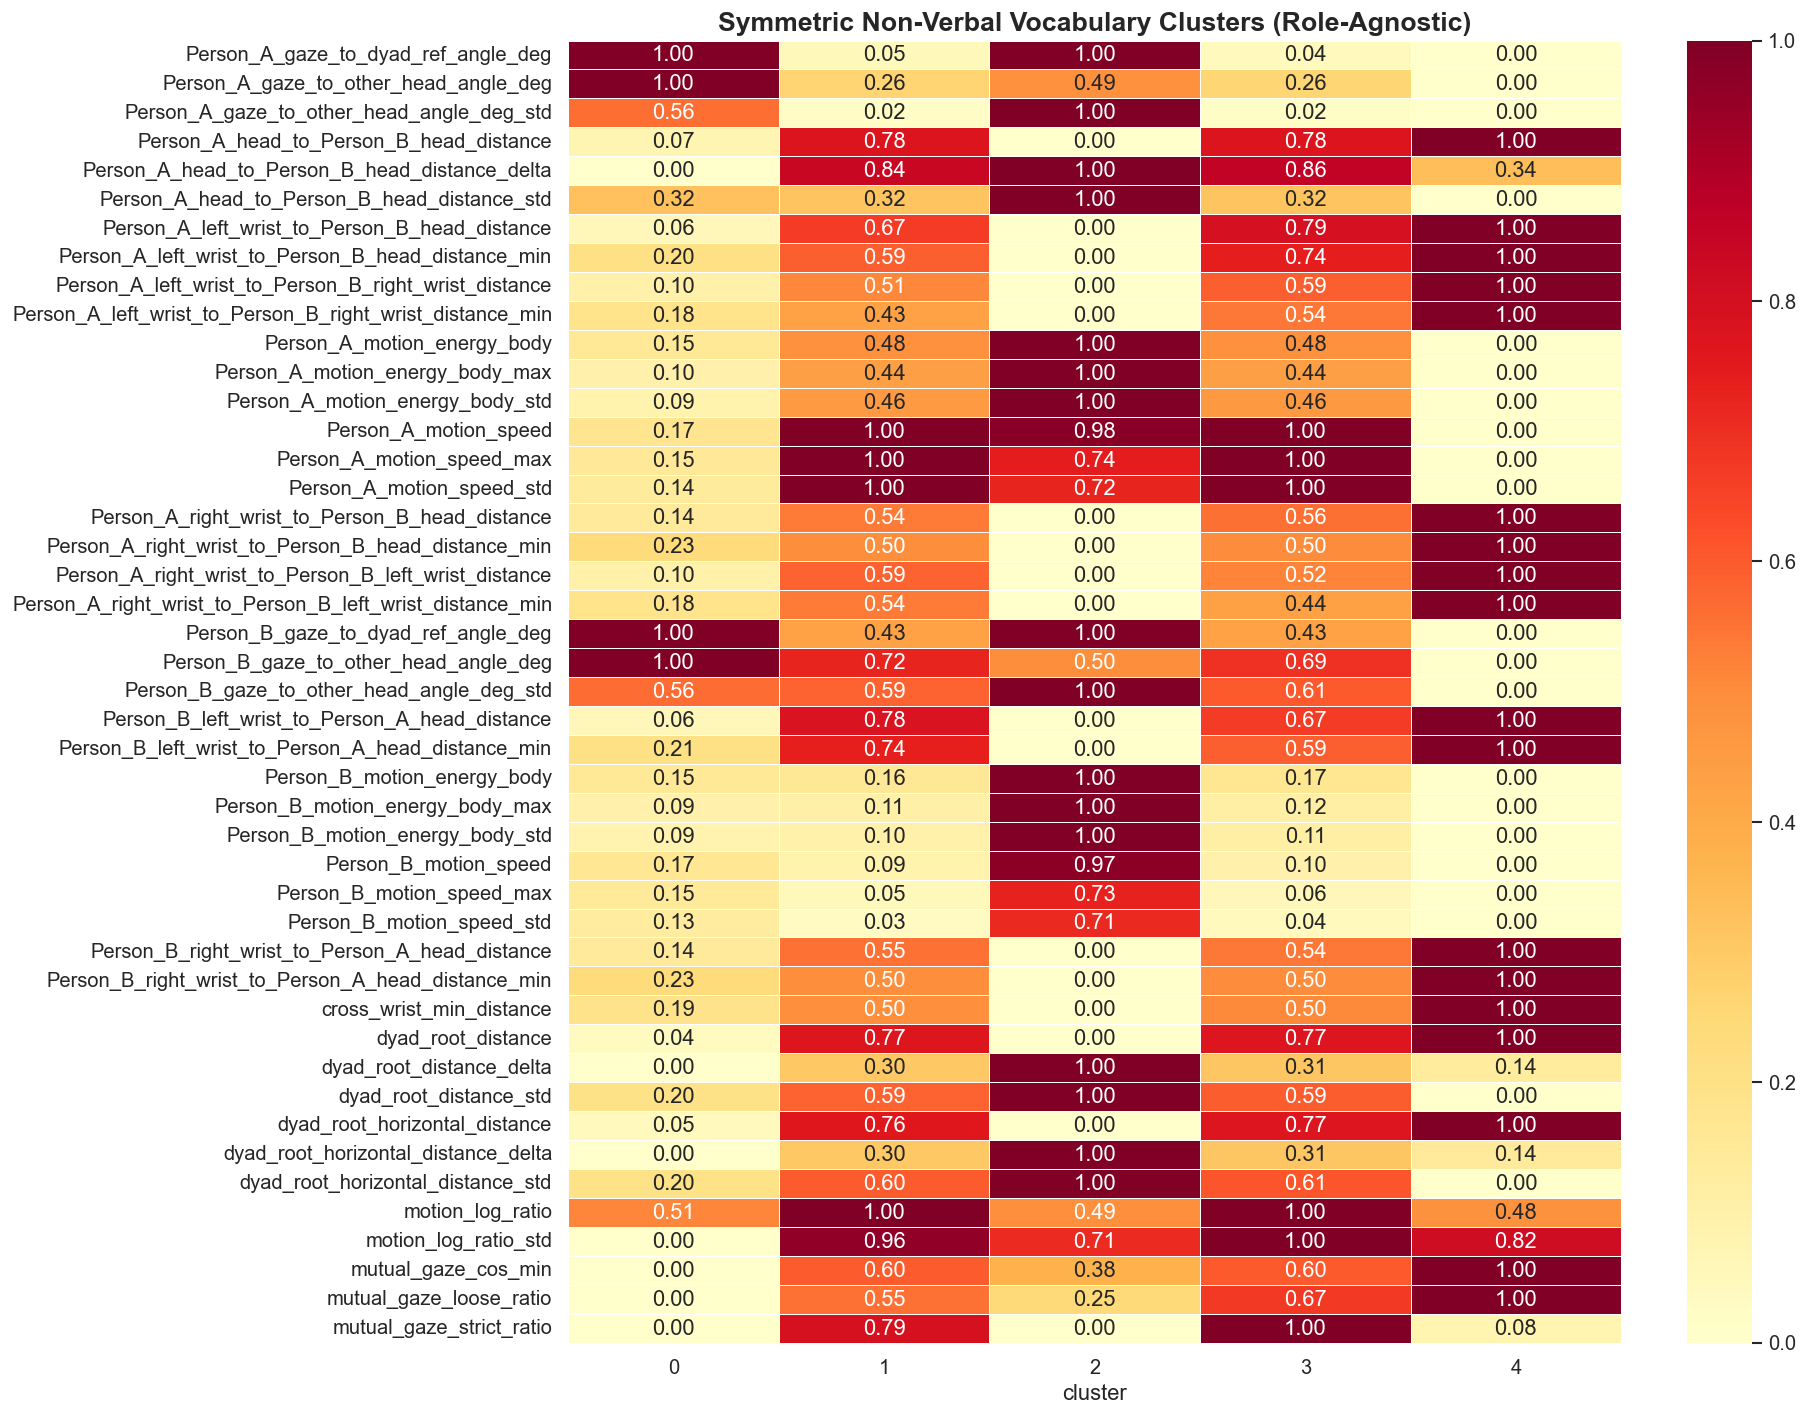

In [5]:
profiles = window_clean.groupby('cluster')[feature_cols].mean()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

# Rename function for display
def rename_for_display(c):
    c = c.replace('_mean', '').replace('p1_', 'Person_A_').replace('p2_', 'Person_B_')
    return c

profiles_norm.columns = [rename_for_display(c) for c in profiles_norm.columns]

# Ensure Person A is always the more active one in asymmetric clusters for readability
# (Swap A/B names in the heatmap if B is faster)
for idx in profiles_norm.index:
    speed_a = profiles_norm.loc[idx, 'Person_A_motion_speed']
    speed_b = profiles_norm.loc[idx, 'Person_B_motion_speed']
    # if B is faster, we visually swap them in the row so the heatmap always 
    # shows "Person A" as the primary actor.
    if speed_b > speed_a:
        for c in list(profiles_norm.columns):
            if c.startswith('Person_A_') and 'Person_B_' not in c:
                b_col = c.replace('Person_A_', 'Person_B_')
                # swap values
                temp = profiles_norm.loc[idx, c]
                profiles_norm.loc[idx, c] = profiles_norm.loc[idx, b_col]
                profiles_norm.loc[idx, b_col] = temp
        # also invert motion_log_ratio
        if 'motion_log_ratio' in profiles_norm.columns:
            profiles_norm.loc[idx, 'motion_log_ratio'] = 1.0 - profiles_norm.loc[idx, 'motion_log_ratio']

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(profiles_norm.T.sort_index(), annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
ax.set_title('Symmetric Non-Verbal Vocabulary Clusters (Role-Agnostic)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('symmetric_heatmap.png', dpi=150)
plt.show()


## 5. Permutation Test for Symmetric Clusters

In [6]:
# We prove the symmetric clusters are statistically significant
N_PERM = 100
rng = np.random.RandomState(42)
s_null = np.zeros(N_PERM)
s_obs = silhouette_score(X, window_clean['cluster'].values, sample_size=2000)

print(f"Running {N_PERM} permutations...")
for i in range(N_PERM):
    X_perm = X.copy()
    for col_idx in range(X_perm.shape[1]):
        rng.shuffle(X_perm[:, col_idx])
    labels_perm = KMeans(n_clusters=K, random_state=42, n_init=5).fit_predict(X_perm)
    s_null[i] = silhouette_score(X_perm, labels_perm, sample_size=2000)

p_val = np.mean(s_null >= s_obs)
print(f"Permutation p-value: {p_val:.4f} (Observed: {s_obs:.4f}, Null Mean: {s_null.mean():.4f})")


Running 100 permutations...
Permutation p-value: 0.0000 (Observed: 0.0733, Null Mean: 0.0140)
